In [402]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from shapely import points, contains
import random

In [2]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "test"

In [292]:
def meta_one_hot_shot(meta, para_nm):
    meta = meta.transpose()
    meta_one_hot = pd.DataFrame(False, index=meta.index, columns=para_nm)
    for index, row in meta.iterrows():
        for r in row.values:
            meta_one_hot.loc[index, para_nm[r]] = True

    return meta_one_hot

In [293]:
class EmulatedDataStorage:
    """
    Lightweight container for emulation outputs.
    No computation logic.
    """
    def __init__(self):
        pass

In [331]:
def sample_from_hull(X, para, h):
    pts = points(X[list(para)].values)
    tf = contains(h,pts)
    
    return X.loc[tf].reset_index(drop=True)

In [390]:
def sample_from_hull_above_n(para_l, para_nm, grouped_hulls, n_pts = 100000, n_threshold = 100000):
    out = []
    count = 0
    while count < n_pts:
        X = pd.DataFrame(np.random.uniform(0, 1, (n_pts, len(para_nm))), columns = para_nm)
        for para in para_l:
            h = grouped_hulls[para]    
            X = sample_from_hull(X, para, h)
            
            if X.shape[0] = 0:
                print(f'Break by {para}')
                return None
            
        out.append(X)
        count = count + X.shape[0]
                
    out = pd.concat(out, axis = 0)
    return out

In [ ]:
def sample_explore(para_nm, grouped_hulls, n_pts = 100000):
    para 
    ss

In [ ]:
def chain_sampling(para, para_nm, grouped_hulls, n_pts = 10000):
    

In [332]:
def sample_from_hulls(X, paras, grouped_hulls):
    X = X
    for p in paras:
        h = grouped_hulls[p]
        X = sample_from_hull(X, p, h)
        
    return X, X.shape[0]

In [354]:
class HistoryMatching:
    def __init__(self, working_dir, case_name, threshold_level = 2.0):
        self.root = Path(working_dir) / case_name
        self.tf_masks = pd.read_csv(self.root / f'tf_masks_level_{threshold_level}.csv', index_col=0)
        self.meta = pd.read_csv(self.root / 'meta.csv', index_col = 0)
        self.p_emu = xr.open_dataset(self.root / 'sampled_parameters.nc').to_dataframe()
        self.var_nm = list(self.tf_masks.columns)
        self.para_nm = list(self.p_emu.columns)

        self.tf_masks_raw = self.tf_masks

        self.dropped_vars = EmulatedDataStorage()
        self.n_sample = self.tf_masks.shape[0]

        self.dropped_vars.nooverlap2d = []
    def drop_by_name(self, var_to_exclude):
        var_to_drop = []
        for v in var_to_exclude:
            var_to_drop.extend([s for s in self.var_nm if s.startswith(v)])
        
        self.tf_masks = self.tf_masks.drop(columns = var_to_drop)

        self.var_nm = list(self.tf_masks.columns)
        self.dropped_vars.by_name = var_to_drop

    def drop_by_n_survive(self, n_survive):
        survive_summary = self.tf_masks.sum(axis = 0)
        self.dropped_vars.useless = list(survive_summary[survive_summary == self.n_sample].index)
        self.dropped_vars.tight   = list(survive_summary[survive_summary < n_survive].index)

        self.tf_masks = self.tf_masks.drop(columns = self.dropped_vars.useless + self.dropped_vars.tight)
        
        self.var_nm = list(self.tf_masks.columns)

    def update_meta(self, occurence_threshold = 2):
        self.meta = self.meta[self.var_nm]
        self.meta_onehot = meta_one_hot_shot(self.meta, self.para_nm)
        p_occur_count = self.meta_onehot.sum(axis = 0)
        self.p_occur_count = p_occur_count
        
#        p_sensitive = list(p_occur_count[p_occur_count > occurence_threshold].index)
#        self.meta_onehot = self.meta_onehot[p_sensitive]

    def hull_for_each(self, shape_alpha = 5):
        hull_per_var = {}
        for v in self.var_nm:
            p_ind = self.meta[v].sort_values().values
            pts = self.p_emu[self.tf_masks[v]].iloc[:,p_ind]
            if pts.shape[0] > 5000:
               pts = pts.sample(5000)

            pts = pts.values
            
            hull_per_var[v] = alphashape.alphashape(pts, shape_alpha)

        self.hull_per_var = hull_per_var

    def group_para_climatology(self):

        vars = self.var_nm
        paras_vars = {}
        paras_vars_0 = {}    
        for c in vars: 
            para_inds = self.meta[c].sort_values().values
            para_nms = [self.para_nm[ind] for ind in para_inds]
            paras_vars.setdefault(tuple(para_nms), []).append(c)



        paras_vars = dict(
                sorted(paras_vars.items(), key=lambda item: len(item[1]), reverse=True)
        )
        
        self.paras_vars = paras_vars
        
        
        for k, v in paras_vars.items():
            temp_count = self.tf_masks[v].all(axis = 1).sum()
            print(f'{k[0]:<40} and {k[1]:<40}: {temp_count:>8}')
            if temp_count < 10000:
                paras_vars_0[k] = v

        self.paras_vars_0 = paras_vars_0

        
        
    def shuffle_vars(self, n_comb = 2):
        summary_table = {}
    
        for paras, vars in self.paras_vars_0.items():
            
            vars_temp = vars 
            pd_list = []
            
            for vars_comb in combinations(vars_temp, n_comb):
                pd_list.append(list(vars_comb) + [self.tf_masks[list(vars_comb)].all(axis = 1).sum()])
                
            pd_list = pd.DataFrame(pd_list, columns = [f"var{i+1}" for i in range(n_comb)] + ["count"])
            pd_list = pd_list.sort_values(by = "count")
            
            
            summary_table[paras] = pd_list

        print(f'There are {len(self.paras_vars_0)} groups that have no overlapping within own groups')
        return summary_table

    def drop_no_overlap2d_vars(self, vars_to_drop):
        self.tf_masks = self.tf_masks.drop(columns = vars_to_drop)
        self.var_nm = list(self.tf_masks.columns)
        self.meta = self.meta[self.var_nm]
        self.meta_onehot = meta_one_hot_shot(self.meta, self.para_nm)
        self.dropped_vars.nooverlap2d.append(vars_to_drop)

        
    
    def visualize(self, para_pair):
        para_pair = tuple(para_pair)
        survive_pts = self.p_emu[self.tf_masks[self.paras_vars[para_pair]].all(axis = 1)]

        if survive_pts.shape[0] > 5000:
            survive_pts = survive_pts.sample(5000)

        return survive_pts

    def build_hulls(self, shape_alpha = 5):
        grouped_hulls = {}

        for para2, vars in self.paras_vars.items():

            tf_mask = self.tf_masks[vars].all(axis = 1)
            pts = self.p_emu[tf_mask]
            if pts.shape[0] > 5000:
                pts = pts.sample(5000)
            
            pts_np = pts[list(para2)].values
            
            grouped_hulls[para2] = alphashape.alphashape(pts_np, shape_alpha)
            
            
        self.grouped_hulls = grouped_hulls
    
    def sample_short_chain(self, n_pts = 100000, n_comb = 2):
        para_tuple = list(combinations(list(self.paras_vars.keys()),n_comb))
        r_pts = pd.DataFrame(np.random.uniform(0, 1, (n_pts, len(self.para_nm))), columns = self.para_nm)    
        
        def _worker(p2s):
            return p2s, sample_from_hulls(r_pts, p2s, self.grouped_hulls)[1]
        
        out = {}
        with ThreadPoolExecutor(max_workers=31) as ex:
            for k, v in ex.map(_worker, para_tuple):
                out[k] = v


        out = sorted(out.items(), key=lambda x: x[1])

        return out



    

In [355]:
test_case = HistoryMatching(working_dir, case_name)
test_case.drop_by_name(["TGCLDLWP", "CLDTOT"])
test_case.drop_by_n_survive(n_survive = 100000)
test_case.update_meta()

In [356]:
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()

clubb_C8                                 and microp_aero_wsub_min                    :   314967
clubb_C8                                 and microp_aero_wsubi_scale                 :    48436
dust_emis_fact                           and microp_aero_wsubi_scale                 :        0
clubb_c14                                and microp_aero_wsubi_scale                 :   176779
micro_mg_berg_eff_factor                 and microp_aero_wsubi_scale                 :        0
clubb_c2rt                               and zmconv_dmpdz                            :   869194
clubb_c2rt                               and microp_aero_wsubi_scale                 :        0
clubb_C8                                 and zmconv_capelmt                          :        0
clubb_C8                                 and cldfrc_dp1                              :   684794
zmconv_capelmt                           and seasalt_emis_scale                      :   548406
clubb_c14                               

In [357]:
no_overlap_2d_vars = ["FLUT_zonal_55to60", 'LWCF_zonal_-70to-65', 'FLUT_zonal_-60to-55', 
                      'FLUT_zonal_-55to-50', 'FLUT_zonal_-65to-60', 'SWCF_zonal_-60to-55', 
                      'SWCF_zonal_-55to-50', 'LWCF_zonal_70to75', 'LWCF_zonal_65to70', 'LWCF_zonal_30to35']

In [358]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()

clubb_C8                                 and microp_aero_wsub_min                    :   314967
clubb_C8                                 and microp_aero_wsubi_scale                 :    48436
dust_emis_fact                           and microp_aero_wsubi_scale                 :    70638
clubb_c14                                and microp_aero_wsubi_scale                 :   176779
clubb_c2rt                               and zmconv_dmpdz                            :   869194
clubb_C8                                 and cldfrc_dp1                              :   684794
micro_mg_berg_eff_factor                 and microp_aero_wsubi_scale                 :   813089
zmconv_capelmt                           and seasalt_emis_scale                      :   548406
clubb_c14                                and clubb_c2rt                              :   205458
clubb_c2rt                               and microp_aero_wsubi_scale                 :   126587
micro_mg_berg_eff_factor                

In [359]:
test_case.build_hulls()

In [360]:
zz = test_case.sample_short_chain()

In [362]:
zz = sorted(zz.items(), key=lambda x: x[1])

In [367]:
start_tuple = ('clubb_C8', 'microp_aero_wsub_min') 


[((('clubb_C8', 'zmconv_capelmt'), ('clubb_C8', 'microp_aero_wsub_scale')), 0),
 ((('clubb_C8', 'microp_aero_wsub_min'), ('clubb_C8', 'zmconv_capelmt')), 38),
 ((('clubb_C8', 'microp_aero_wsubi_scale'),
   ('clubb_C8', 'microp_aero_wsub_scale')),
  680),
 ((('dust_emis_fact', 'microp_aero_wsubi_scale'),
   ('clubb_C8', 'microp_aero_wsub_scale')),
  713),
 ((('dust_emis_fact', 'microp_aero_wsubi_scale'),
   ('clubb_C8', 'zmconv_capelmt')),
  942),
 ((('clubb_C8', 'microp_aero_wsubi_scale'),
   ('dust_emis_fact', 'microp_aero_wsubi_scale')),
  1017),
 ((('clubb_C8', 'microp_aero_wsubi_scale'),
   ('clubb_c2rt', 'microp_aero_wsubi_scale')),
  1054),
 ((('clubb_c2rt', 'microp_aero_wsubi_scale'),
   ('clubb_C8', 'microp_aero_wsub_scale')),
  1275),
 ((('clubb_C8', 'microp_aero_wsubi_scale'),
   ('zmconv_ke', 'microp_aero_wsubi_scale')),
  1317),
 ((('dust_emis_fact', 'microp_aero_wsubi_scale'), ('clubb_c14', 'clubb_c2rt')),
  1401),
 ((('zmconv_ke', 'microp_aero_wsubi_scale'),
   ('clubb_C8

In [407]:
list(test_case.grouped_hulls.values())[3].bounds

(0.0002854894207144909,
 0.00013600073830510873,
 0.9999568015913585,
 0.41840755376243977)

In [369]:
test_case.paras_vars[('clubb_C8', 'microp_aero_wsub_min')]

['SWCF_zonal_-25to-20',
 'SWCF_zonal_-20to-15',
 'SWCF_zonal_55to60',
 'FSNTOA_zonal_-25to-20',
 'SWCF_zonal_-45to-40',
 'SWCF_zonal_60to65',
 'SWCF_zonal_-50to-45',
 'FSNTOA_zonal_-40to-35',
 'SWCF_zonal_-30to-25',
 'SWCF_zonal_50to55',
 'SWCF_zonal_-40to-35',
 'FSNTOA_zonal_-20to-15',
 'SWCF_zonal_35to40',
 'SWCF_zonal_25to30',
 'FSNTOA_zonal_60to65',
 'FSNTOA_zonal_-45to-40',
 'SWCF_zonal_30to35',
 'FSNTOA_zonal_55to60',
 'FSNTOA_zonal_-30to-25',
 'SWCF_zonal_-35to-30',
 'FSNTOA_zonal_-35to-30']

In [370]:
test_case.paras_vars[('clubb_C8', 'zmconv_capelmt')]

['SWCF_zonal_-65to-60', 'FSNTOA_zonal_-70to-65']

In [400]:
out = sample_from_hull_above_n([('clubb_C8', 'clubb_c2rt'), ('clubb_c1', 'microp_aero_wsubi_scale')], test_case.para_nm, test_case.grouped_hulls)

In [401]:
out.shape

(140025, 34)

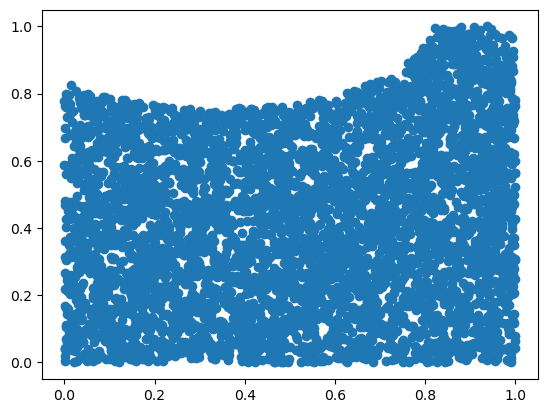

In [194]:
pts3 = test_case.visualize(['microp_aero_wsub_scale', 'microp_aero_wsubi_scale'])
plt.scatter(pts3['microp_aero_wsub_scale'], pts3['microp_aero_wsubi_scale'])

In [191]:
test_case.meta_onehot["clubb_C8"][test_case.meta_onehot["clubb_C8"]]


SWCF_zonal_65to70        True
LWCF_zonal_-35to-30      True
FSNTOA_zonal_15to20      True
SWCF_zonal_-25to-20      True
LWCF_zonal_-45to-40      True
SWCF_zonal_-20to-15      True
FSNTOA_zonal_-5to0       True
SWCF_zonal_55to60        True
FSNTOA_zonal_-25to-20    True
FSNTOA_zonal_45to50      True
FSNTOA_zonal_40to45      True
TMQ_zonal_50to55         True
SWCF_zonal_-15to-10      True
SWCF_zonal_-45to-40      True
SWCF_zonal_60to65        True
SWCF_zonal_-50to-45      True
FSNTOA_zonal_-40to-35    True
SWCF_zonal_-30to-25      True
FLUT_zonal_-40to-35      True
TMQ_zonal_45to50         True
SWCF_zonal_-10to-5       True
SWCF_zonal_50to55        True
FSNTOA_zonal_-50to-45    True
SWCF_zonal_-40to-35      True
FSNTOA_zonal_-20to-15    True
SWCF_zonal_15to20        True
LWCF_zonal_-30to-25      True
FLUT_zonal_-45to-40      True
SWCF_zonal_0to5          True
SWCF_zonal_20to25        True
SWCF_zonal_10to15        True
SWCF_zonal_35to40        True
FLUT_zonal_-35to-30      True
LWCF_zonal

In [39]:
len(test_case.dropped_vars.tight)

48

In [44]:
len(test_case.var_nm)

106

In [26]:
len(test_case.var_nm) + len(test_case.dropped_vars.by_name)+ len(test_case.dropped_vars.tight)+ len(test_case.dropped_vars.useless)

235